# Network based representativeness assessments

In this notebook, we will represent grain structres as network graphs and compare them for similarities. We will use the following metrics:
1. Wasserstein distance measure
2. Energy distance measure
3. Jaccard similarity measure
4. Kalmogorov - Smirnov test P-statistic metric
5. NetLSD metric

We will generate a temporal set of sample and target grain structures and then compare the two sets to identify grain strucure pairs with high representativeness metric. We will go through some details before we dive into the code parts

## Network Representativeness Metrics

This notebook employs several statistical and graph-theoretic metrics to quantify the similarity between sample and target grain structure networks. These metrics assess **representativeness** by comparing distributions of network properties (degree sequences, centrality measures) or structural features. Below is an overview of each metric:

---

**Note**: In the UPXO implementation, all metrics are normalized such that **higher values indicate greater representativeness**. This uniform scaling removes ambiguity when comparing different metrics.

---

### 1. Wasserstein distance (WD)

The **Wasserstein distance** (also called Earth Mover's Distance) measures the minimum "cost" to transform one probability distribution into another. In the context of grain networks, it compares distributions of network features (e.g., degree distributions) between sample and target graphs. Lower Wasserstein distance indicates higher similarity, meaning the sample grain structure is more representative of the target.

**Interpretation**: A WD close to 0 suggests the sample network's statistical properties closely match the target network.

### 2. Energy Distance (ED)
The **energy distance** is a metric between probability distributions based on the expected distance between random samples from each distribution. It is sensitive to differences in both shape and location of distributions. For grain networks, ED quantifies how different the network feature distributions (e.g., centrality measures) are between sample and target.

**Interpretation**: Higher ED values (closer to 1) indicate higher representativeness; the sample network's structural properties are statistically similar to the target.

### 3. Jaccard Similarity (JS)
The **Jaccard similarity coefficient** measures the similarity between two sets by computing the ratio of their intersection to their union. In network analysis, it can compare edge sets or node neighborhoods. For grain structure networks, JS assesses overlap in connectivity patterns (e.g., shared grain boundary relationships).

**Interpretation**: JS ranges from 0 (no overlap) to 1 (identical networks). Higher JS indicates the sample network shares more structural features with the target.

### 4. Kolmogorov-Smirnov Test P-Statistic (KSP)
The **Kolmogorov-Smirnov (KS) test** is a non-parametric test that compares two cumulative distribution functions (CDFs). The KS statistic quantifies the maximum difference between CDFs of sample and target network features (e.g., degree distributions). The associated p-value indicates whether the distributions are significantly different.

**Interpretation**: A higher p-value (closer to 1) suggests the distributions are statistically indistinguishable, meaning the sample network is representative of the target. A low p-value indicates significant differences.

### 5. NetLSD (Network Laplacian Spectral Descriptor)
**NetLSD** is a graph similarity metric based on the spectral properties of the graph Laplacian matrix. It computes a signature (heat trace) that captures global graph structure, including connectivity and clustering patterns. NetLSD is scale-invariant and suitable for comparing graphs of different sizes.

**Interpretation**: NetLSD distance close to 0 indicates high structural similarity. It is particularly effective for comparing microstructure networks with varying grain counts or topologies.

---

### Application to Grain Structure Networks
In this notebook, grain structures are represented as **spatial networks** where:
- **Nodes** represent grains
- **Edges** represent grain boundaries (spatial adjacency)

By computing these metrics across temporal slices of sample and target grain structures, we identify pairs with high representativeness—i.e., sample configurations that statistically and topologically resemble the target microstructure. This enables validation of synthetic grain structures against experimental or reference data.

In [46]:
from upxo.repqual.grain_network_repr_assesser import KREPR
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Parameters for generating target set
These will form the reference against which, comparisons will be made.
* Domain size: 100 x 100
* mcalg: 200
* Number of states: 10
* Total number of temporal steps = 50
* Boltzmann temperature: 0

In [47]:
Sample_input_dashboard = 'C:\\Development\\UPXO\\upxo_library\\src\\upxo\\demos\\repassess\\sample.xls'

## Parameters for generating the sample set
* Domain size: 100 x 100
* mcalg: 200
* Number of states: 10
* Total number of temporal steps = 50
* Boltzmann temperature: 0.25

In [48]:
Target_input_dashboard = 'C:\\Development\\UPXO\\upxo_library\\src\\upxo\\demos\\repassess\\target.xls'

## Set up the temporal steps and time increments to consider

In [49]:
Msample, Mtarget = 29, 29
MsampleIncr, MtargetIncr = 1, 1

## Set upthe neighbour order. 

UPXO allws you to cosider fractional values, where the decimal parts is interpretated probabilistically. That is, a value of 3.3 would indicate all the neighbours upto 3rd order and inclsive of a 30 % of the only the 4th order neighbours

In [ ]:
neighOrder = [1.0, 3.5]

## Generate the sample and target grain structure datasets

In [51]:
kr = KREPR.from_gsgen(gstype_tgt='mcgs2d',
                      gstype_smp='mcgs2d',
                      is_smp_same_as_tgt = False,
                      characterize_tgt=True, characterize_smp=True,
					  tgt_dashboard=Sample_input_dashboard,
					  smp_dashboard=Target_input_dashboard,
					  ordern=neighOrder,
                      tsid_source='user', ssid_source='user',
					  tid=np.arange(1, Mtarget, MtargetIncr),
                      sid=np.arange(1, Msample, MsampleIncr),
                      _cim_='from_gsgen')

GENERATING TARGET GRAIN STRUCTURES
C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs
C:\Development\UPXO\upxo_library\src\upxo\demos\repassess\sample.xls
Algo_hops details
(('200.0', 100),)
[False]

 Initiating Monte-Carlo simulation
     xmin, xmax, xinc: 0.0, 100.0, 1.0
     ymin, ymax, yinc: 0.0, 100.0, 1.0
     zmin, zmax, zinc: 0.0, 100.0, 1.0
     No. of states: 10
     Dimensionality: 2
Using ALG-200: SA's SL NL-1 TP1 C2 unweighted Q-Pott's model:
|--------------- MC SIM RUN IN PROGRESS on: ALG200---------------|
GS temporal slice 0 stored
GS temporal slice 1 stored
GS temporal slice 2 stored
GS temporal slice 3 stored
GS temporal slice 4 stored
GS temporal slice 5 stored
GS temporal slice 6 stored
GS temporal slice 7 stored
GS temporal slice 8 stored
GS temporal slice 9 stored
GS temporal slice 10 stored
GS temporal slice 11 stored
GS temporal slice 12 stored
GS temporal slice 13 stored
GS temporal slice 14 stored
GS temporal slice 15 stored
GS temporal slice 16 

## We will now set up the tests we intend to make. Just turn the appropriate ones True to perform and False to ignore

In [52]:
kr.set_rkf(js=True, wd=True, ksp=True, ed=True, nlsd=True,
           degcen=False, btwcen=False, clscen=False, egnvcen=False)

----------------------------------------
Creating R-field data structures.


## We will now calculate the appropriate Network Representativeness metric measures

The `calculate_rkf()` method computes all enabled representativeness metrics across sample-target grain structure pairs. It processes each neighbor order and temporal instance combination to generate comprehensive similarity assessments.

**What happens during execution:**

- **Pairwise comparison**: For each sample temporal instance (row) and target temporal instance (column), the method extracts network features (degree distributions, centrality measures, spectral signatures) and computes the enabled metrics (WD, ED, JS, KSP, NetLSD).
- **Neighbor order handling**: Computations are performed separately for each neighbor order specified during setup (e.g., `neighOrder = [1.0, 3.5]`), capturing how similarity varies with spatial connectivity scale.
- **Normalization**: All metrics are scaled to [0, 1] where higher values indicate greater representativeness—ensuring consistent interpretation across different measures.
- **Storage**: Results are stored in internal dictionaries (`kr.rkf_*`) indexed by `neighbor_order`.

**Performance notes:**

- Computational cost scales with `len(sid) × len(tid) × len(neigh_orders)`.
- Major performance cost is the characterisaiton phase pre-netork build up. This is an active code optimization problem I am workoing on. Expect this to change soon. 
- NetLSD is more expensive than distribution-based metrics (WD, KSP) but provides global structural insights.
- For large temporal sets (>50 instances per set), consider reducing `MsampleIncr`/`MtargetIncr` or limiting neighbor orders.

**Output:**

No return value—results are stored in the `KREPR` instance. Use `kr.plot_rkf()` to visualize or access raw data via `kr.rkf_wd`, `kr.rkf_ed`, etc.

In [53]:
kr.calculate_rkf()

++++++++++++++++++++++++++++++++++++++
[1.0, 10] -------------
++++++++++++++++++++++++++++++++++++++
----------------------------------------
Calculating R-field.
     O(n): 1.0, gsID pair: (5-20)
     O(n): 1.0, gsID pair: (10-20)
     O(n): 1.0, gsID pair: (15-20)
     O(n): 1.0, gsID pair: (20-20)
     O(n): 1.0, gsID pair: (25-20)
----------------------------------------
Calculating R-field.
     O(n): 10, gsID pair: (5-20)
     O(n): 10, gsID pair: (10-20)
     O(n): 10, gsID pair: (15-20)
     O(n): 10, gsID pair: (20-20)
     O(n): 10, gsID pair: (25-20)


## View the results as a map.

The `plot_rkf()` method visualizes representativeness metrics as heatmaps, comparing sample and target grain structure temporal instances. Each heatmap shows a specific metric (WD, ED, JS, KSP, or NetLSD) for a given neighbor order.

**Key parameters:**

- **`neigh_orders`**: List of neighbor orders to plot (e.g., `[1.0, 3.5]`). One heatmap per order.
- **`power`**: Exponent for scaling metric values (default: 1). Use values > 1 to emphasize high-representativeness pairs.
- **`figsize`, `dpi`**: Figure dimensions and resolution.
- **`xtick_incr`, `ytick_incr`**: Tick label intervals for temporal instance indices.
- **`cmap`**: Colormap for heatmap (e.g., `'nipy_spectral'`, `'RdYlGn'`).
- **`cbarticks`, `cbfs`**: Colorbar tick positions and font size.
- **`flags`**: Dictionary to toggle which metric to display. Set **one** metric to `True`, others to `False` (e.g., `{'rkf_wd': True, ...}` for Wasserstein distance).

**Interpretation:**

- **Rows**: Sample temporal instances (y-axis).
- **Columns**: Target temporal instances (x-axis).
- **Color intensity**: Higher values (warmer colors) indicate greater representativeness—the sample instance at that row better matches the target instance at that column.

Use this to identify optimal sample-target pairs for validation or to track how representativeness evolves over simulation time.

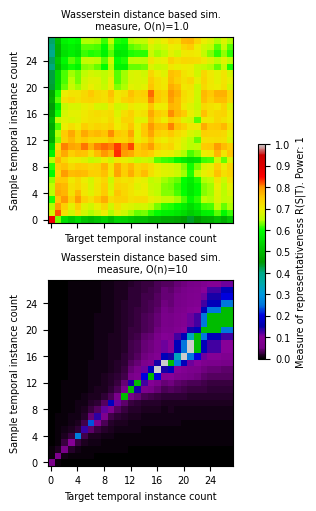

In [54]:
kr.plot_rkf(neigh_orders=neighOrder, power=1, figsize=(7, 5), dpi=100,
            xtick_incr=4, ytick_incr=4, lfs=7, tfs=7,
            cmap='nipy_spectral', cbarticks=np.arange(0, 1.1, 0.1), cbfs=7,
            cbtitle='Measure of representativeness R(S|T)',
            cbfraction=0.046, cbpad=0.04, cbaspect=30, shrink=0.5,
            cborientation='vertical',
            flags={'rkf_js': False, 'rkf_wd': True,
                   'rkf_ksp': False, 'rkf_ed': False,
                   'rkf_nlsd': False, 'rkf_degcen': False,
                   'rkf_btwcen': False, 'rkf_clscen': False,
                   'rkf_egnvcen': False}, xlabel='Target temporal instance count',
                 ylabel='Sample temporal instance count',)

# Access undelrying grain structue data
You can still access all the underlying grain structure data. They are all stored in the atribute sgset and tgset, sample and target grain strucure set respectively. See for edxample, `kr.sgset[5].plotgs(title='')`, which plots the below grain structure.

![GRAIN STRUCTURE ACCESS EXAPLE](repa2a.png)